In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score
from sklearn.model_selection import LeaveOneOut,KFold,train_test_split
from xgboost import XGBRegressor
from itertools import product

In [19]:
data = pd.read_excel('Microwave_Pyrolysis_Dataset.xlsx')
data = data.drop(columns = ['No.','Ref','Catalyst','Biomass'])

train_data,test_data = train_test_split(data, test_size= 0.2, random_state=42 )

X = train_data.drop(['Gas yield','Char yield','Oil yield'], axis =1, inplace = False)
y = train_data['Char yield']


x_cv = test_data.drop(['Gas yield','Char yield','Oil yield'], axis =1, inplace = False)
y_cv = test_data['Char yield']

In [20]:
parameter = {
    'n_estimators': [100,150],
    'max_depth':[1,4],
    'learning_rate':[0.1,0.01]
}

#the product give teh iterator with all the combunation... we cahnge it to list
para_combinations = list(product(parameter['n_estimators'],parameter['max_depth'],parameter['learning_rate']
))

best_mse = float('inf')
best_para = None
max_depth_hist = []
mse_mean = []

for n_estimators,max_depth,learning_rate in para_combinations:
  model = XGBRegressor(
                        n_estimators = n_estimators,
                        max_depth= max_depth,
                        learning_rate = learning_rate,
                        reg_lambda= 0.1,
                        random_state=42)

  loo = LeaveOneOut()
  #loo= KFold(n_splits=5,random_state=1,shuffle=True)
  mse_hist = []

  for train_ind,test_ind in loo.split(y):
    # note we must have the y also passed ti the liis split to make it know whta teh index

    x_train,y_train,x_test,y_test= X.iloc[train_ind],y.iloc[train_ind],X.iloc[test_ind],y.iloc[test_ind]

    model.fit(x_train,y_train)
    y_pred = model.predict((x_test))
    mse = mean_squared_error(y_pred,y_test)
    mse_hist.append(mse)

  mse = np.mean(mse_hist)


  if mse < best_mse:
    best_mse = mse
    best_para= {
        'n_estimators': n_estimators,
        'max_depth':max_depth,
        'learning_rate':learning_rate

    }



{'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1}
Char Yield
MSE : 183.8546615048747
MAE:6.8901229385896166
MAPE : 4871695650926220.0
R2 test score : 0.4595168137181127
R2 train score : 0.9332679909789786


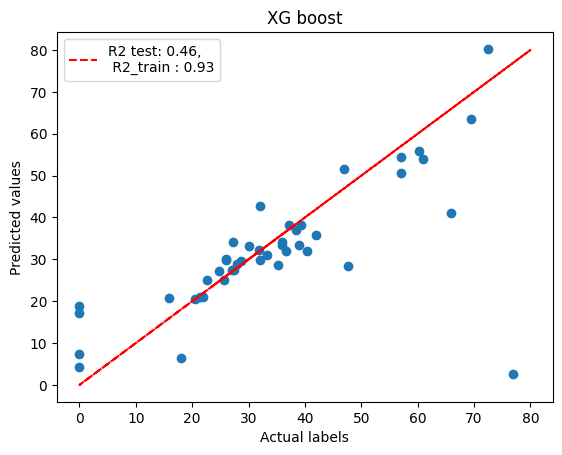

In [21]:
best_model = XGBRegressor(**best_para,reg_lambda= 0.1,random_state=42)

print(best_para)
best_model.fit(X,y)
y_p_tr = best_model.predict(X)
y_pred = best_model.predict(x_cv)

r2_train = r2_score(y,y_p_tr)
mse = mean_squared_error(y_cv,y_pred)
mae = mean_absolute_error(y_cv,y_pred)
mape = mean_absolute_percentage_error(y_cv,y_pred)
r2 = r2_score(y_cv,y_pred)

print('Char Yield')
print(f'MSE : {mse}')
print(f'MAE:{mae}')
print(f'MAPE : {mape}')
print(f'R2 test score : {r2}')
print(f'R2 train score : {r2_train}')

plt.plot(y,y,'r--',label = 'Ideal')
plt.scatter(y_cv,y_pred,label='Actual prediction')
plt.xlabel('Actual labels')
plt.ylabel('Predicted values')
plt.title('XG boost')
plt.legend([f'R2 test: {r2:0.2f},\n R2_train : {r2_train:0.2f}'])
plt.show()